# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

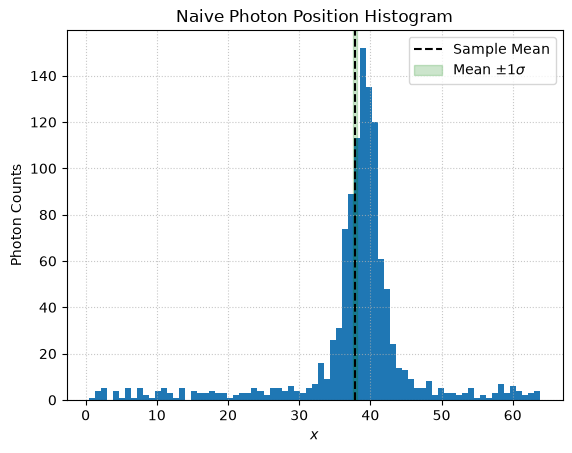

x_0 = 37.841 +- 0.264


In [1]:
# Part 1: your work here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load file
datafile = "./data/ahuwer2.csv"
data = pd.read_csv(datafile)
xs = data['x']
N = len(xs)

# find mean and error
mean = np.mean(xs)
s = np.std(xs)
sigma = s/np.sqrt(N)

# plot
plt.hist(xs, 75)
plt.axvline(mean, linestyle='--', color='k', label='Sample Mean')
plt.axvspan(mean-sigma, mean+sigma, color='g', alpha=0.2, label='Mean $\\pm1\\sigma$')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('$x$')
plt.ylabel('Photon Counts')
plt.title('Naive Photon Position Histogram')
plt.legend()
plt.show()

print(f'x_0 = {mean:.3f} +- {sigma:.3f}')

**ANSWER (a few sentences):**

Visually, it's easy to tell that the estimator is slightly biased towards zero, since the baseline photon counts in the "background" regions (roughly speaking, $0\leq x\leq32$ and $48\leq x\leq60$) will affect the mean. Specifically, since the left tail is longer and both tails are approximately constant in counts relative to the peak, the mean gets shifted left of where it would be without a background signal. As a result, the main thing controlling the size of the bias in this case would be the signal to background noise ratio. If we, say, saw background counts 5 times larger on average, then we might expect the leftward bias to be 5 times larger as we are processing/performing statistical analysis on more data (photons) that are not actually part of the main signal.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

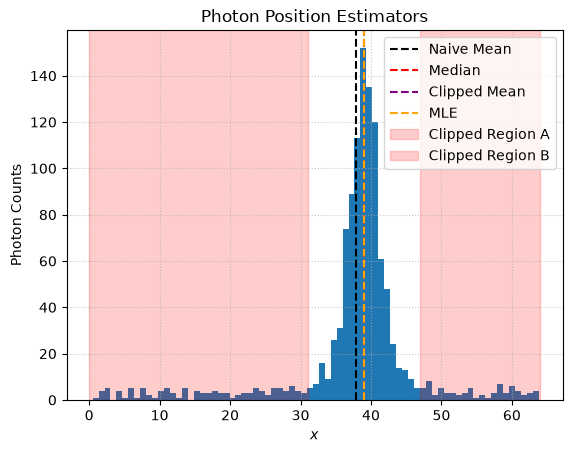

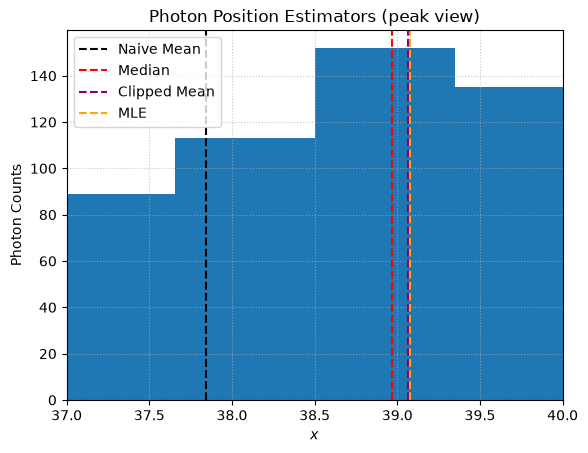

Naive mean: x_0 = 37.841 +- 0.264
Median: x_0 = 38.967 +- 0.107
Clipped mean: x_0 = 39.063 +- 0.094 (n_sigma=3.5, clipped 184/1137)
Mixture Model: x_0 = 39.076 +- 0.082, f_bg = 0.199 +- 0.014
Cramer-Rao bound on x_0: 0.082
3x Cramer-Rao bound for comparision: 0.2465


In [2]:
# Part 2: your work here
from scipy.special import gamma
from scipy.optimize import minimize
from scipy.integrate import quad

beta = 2.5
r0 = 4.0
window = (0.0, 64.0)
bg_width = window[1] - window[0] # should be 64
#print(f'Background width (should be 64): {bg_width}')

### median ###
median = np.median(xs)

# use bootstrapping to get error
n_boot = 5000
boot_medians = np.array([np.median(np.random.choice(xs, N, replace=True)) for i in range(n_boot)])
median_sigma = np.std(boot_medians, ddof=1)



### Sigma-Clipped Mean ###
# chose 3.5 sigma here as it clips right about where you start to see an increase
# in the counts (curvature of the histogram) and isn't clipping so many values that
# we begin to exclude significant real data
n_sigma = 3.5
clip_mask = np.ones(N, dtype=bool)
center = median

for i in range(2000):
    kept = xs[clip_mask]
    center_new = np.mean(kept)
    mad = np.median(np.abs(kept - np.median(kept)))
    robust_std = 1.4826 * mad

    new_mask = np.abs(xs - center_new) <= n_sigma * robust_std
    if np.array_equal(new_mask, clip_mask):
        break
    clip_mask = new_mask
    center = center_new

n_boot = 2000
clipped_mean = np.mean(xs[clip_mask])
n_clipped = N - clip_mask.sum()

# find error with bootstrapping because using the 
boot_clipped_means = np.empty(n_boot)
for b in range(n_boot):
    sample = np.random.choice(xs, N, replace=True)

    # rerun the clipping loop on this resample
    mask_b = np.ones(N, dtype=bool)
    for _ in range(20):
        kept_b = sample[mask_b]
        center_b = np.mean(kept_b)
        mad_b = np.median(np.abs(kept_b - np.median(kept_b)))
        robust_std_b = 1.4826 * mad_b
        new_mask_b = np.abs(sample - center_b) <= n_sigma * robust_std_b
        if np.array_equal(new_mask_b, mask_b):
            break
        mask_b = new_mask_b

    boot_clipped_means[b] = np.mean(sample[mask_b])

clipped_sigma = np.std(boot_clipped_means, ddof=1)

### Mixture-model MLE ###
# p(x | x0, fbg) = fbg/bg_width + (1-fbg) * Moffat(x; x0, r0, beta)
moffat_norm = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def pdf(x, x0, fbg):
    u = (x - x0) / r0
    star = (1 - fbg) * moffat_norm * (1 + u**2) ** (-beta)
    bg = fbg / bg_width
    return bg + star

def neg_log_like(params):
    x0, fbg = params
    if not (0 < fbg < 1):
        return np.inf
    p = pdf(xs, x0, fbg)
    return -np.sum(np.log(p))

res = minimize(neg_log_like, x0=[median, 0.1], method='Nelder-Mead',
                bounds=[(xs.min(), xs.max()), (1e-6, 1 - 1e-6)])
x0_mle, fbg_mle = res.x

# uncertainty from where chi^2 = -2 ln L rises by 1 above its minimum,
# i.e. where -ln L rises by 0.5 -- profiling out the other parameter
# at each trial value
from scipy.optimize import brentq, minimize_scalar

nll_min = neg_log_like([x0_mle, fbg_mle])

def profile_nll_x0(x0_val):
    # hold x0 fixed, re-maximize over fbg only
    res_p = minimize_scalar(lambda fbg: neg_log_like([x0_val, fbg]),
                             bounds=(1e-6, 1 - 1e-6), method='bounded')
    return res_p.fun

def delta_x0(x0_val):
    return profile_nll_x0(x0_val) - nll_min - 0.5

# step outward from the MLE until the profile crosses min+0.5, then root-find
step = 0.05
x_hi = x0_mle + step
while delta_x0(x_hi) < 0:
    x_hi += step
x0_hi = brentq(delta_x0, x0_mle, x_hi)

x_lo = x0_mle - step
while delta_x0(x_lo) < 0:
    x_lo -= step
x0_lo = brentq(delta_x0, x_lo, x0_mle)

x0_mle_sigma = 0.5 * ((x0_hi - x0_mle) + (x0_mle - x0_lo))  # symmetrized 1-sigma

# same idea, now for fbg
def profile_nll_fbg(fbg_val):
    # hold fbg fixed, re-maximize over x0 only
    res_p = minimize_scalar(lambda x0_val: neg_log_like([x0_val, fbg_val]),
                             bounds=(xs.min(), xs.max()), method='bounded')
    return res_p.fun

def delta_fbg(fbg_val):
    return profile_nll_fbg(fbg_val) - nll_min - 0.5

step = 0.01
f_hi = fbg_mle + step
while f_hi < 1 - 1e-6 and delta_fbg(f_hi) < 0:
    f_hi += step
fbg_hi = brentq(delta_fbg, fbg_mle, f_hi)

f_lo = fbg_mle - step
while f_lo > 1e-6 and delta_fbg(f_lo) < 0:
    f_lo -= step
fbg_lo = brentq(delta_fbg, f_lo, fbg_mle)

fbg_mle_sigma = 0.5 * ((fbg_hi - fbg_mle) + (fbg_mle - fbg_lo))

### Cramer-Rao bound (joint 2x2 Fisher matrix for x0 and fbg) ###
# evaluate the Fisher info at the MLE point estimate
def dpdx0(x, x0, fbg):
    u = (x - x0) / r0
    return (1 - fbg) * moffat_norm * (2 * beta * u / r0) * (1 + u**2) ** (-beta - 1)

def dpdfbg(x, x0, fbg):
    u = (x - x0) / r0
    star_density = moffat_norm * (1 + u**2) ** (-beta)
    return 1 / bg_width - star_density

I00, _ = quad(lambda x: dpdx0(x, x0_mle, fbg_mle) ** 2 / pdf(x, x0_mle, fbg_mle),
              window[0], window[1], limit=200)
I11, _ = quad(lambda x: dpdfbg(x, x0_mle, fbg_mle) ** 2 / pdf(x, x0_mle, fbg_mle),
              window[0], window[1], limit=200)
I01, _ = quad(lambda x: dpdx0(x, x0_mle, fbg_mle) * dpdfbg(x, x0_mle, fbg_mle)
              / pdf(x, x0_mle, fbg_mle), window[0], window[1], limit=200)

fisher = N * np.array([[I00, I01], [I01, I11]])   # total Fisher info for N photons
crb_cov = np.linalg.inv(fisher)
sigma_crb_x0 = np.sqrt(crb_cov[0, 0])



# plot
plt.hist(xs, 75)
plt.axvline(mean, linestyle='--', color='k', label='Naive Mean')
plt.axvline(median, linestyle='--', color='red', label='Median')
plt.axvline(clipped_mean, linestyle='--', color='purple', label='Clipped Mean')
plt.axvline(x0_mle, linestyle='--', color='orange', label='MLE')
plt.axvspan(0,min(kept), color='r', alpha=0.2, label='Clipped Region A')
plt.axvspan(max(kept),64.0, color='r', alpha=0.2, label='Clipped Region B')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('$x$')
plt.ylabel('Photon Counts')
plt.title('Photon Position Estimators')
plt.legend()
plt.show()

# plot again, with different x limits to make the mean differences more visible
plt.hist(xs, 75)
plt.axvline(mean, linestyle='--', color='k', label='Naive Mean')
plt.axvline(median, linestyle='--', color='red', label='Median')
plt.axvline(clipped_mean, linestyle='--', color='purple', label='Clipped Mean')
plt.axvline(x0_mle, linestyle='--', color='orange', label='MLE')
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlabel('$x$')
plt.ylabel('Photon Counts')
plt.title('Photon Position Estimators (peak view)')
plt.legend()
plt.xlim([37, 40])
plt.show()

# results
print(f'Naive mean: x_0 = {mean:.3f} +- {sigma:.3f}')
print(f'Median: x_0 = {median:.3f} +- {median_sigma:.3f}')
print(f'Clipped mean: x_0 = {clipped_mean:.3f} +- {clipped_sigma:.3f} (n_sigma={n_sigma}, clipped {n_clipped}/{N})')
print(f'Mixture Model: x_0 = {x0_mle:.3f} +- {x0_mle_sigma:.3f}, f_bg = {fbg_mle:.3f} +- {fbg_mle_sigma:.3f}')
print(f'Cramer-Rao bound on x_0: {sigma_crb_x0:.3f}')
print(f'3x Cramer-Rao bound for comparision: {3*sigma_crb_x0:.4f}')

**FINAL ANSWER:** $x_0 = $ 39.076 $\pm$ 0.082 px, $f_{\rm bg} = $ 0.199 $\pm$ 0.014, Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.082 px

**Justification and uncertainty method (a short paragraph):**

Let's start by comparing the different methods. The naive case is obviously the most biased, with $\sigma_{naive}=0.264>3\sigma_{CR}=0.247$. However, while the median method is significantly more robust, it's still going to be somewhat biased in the same direction: the background counts being nonzero means there will always be some amount of data "pulling" the median in some direction based on how many background counts are on either side of the actual peak $x_0$. Since these counts are approximately constant (with random variation) around the PSF and the peak is on the right side of the detector, it'll be biased to the left still, just less so. That makes our best options the clipped mean and the mixture model, which are very very close in values. I think the mixture model is the most accurate here though, as we can't be 100% certain that we did not exclude valid data (or included too much invalid data) with the clipping, and the mixture model additionally has an lower x_0 error, equivalent to the Cramer-Rao bound.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

To address closure, we'll create a similar dataset on the same window, with $f_{bg}=0.25$ and $x_0=28$. We'll keep the same $\beta$ and $r_0$ here. Failure here would have the chosen model (in my case, the mixture model) recovering an incorrect value for $f_{bg}=0.25$ or $x_0=28$, or simply having significantly too large or small errors.

For bias and efficiency, we'll do exactly as it states: Monte Carlo all four estimators on many simulated datasets at plausible parameters, then plot their biases and then their variances against the Cramér–Rao bound (for these we can use bar plots). This is just like for closure and failure would be the same: any model with too large/small variances or significant biases versus the randomly-chosen values would likely be incorrect.

For coverage, we also use Monte Carlo. We can pick one set of known values to repeatedly generate, such as the example in the closure section, and if we test many times and values we report are within $1\sigma$ around 68% of the time, then we know the errors should be correct in magnitude. If not, then we've failed to take something into consideration or the model is incorrect.

For sensitivity, we keep $\beta$ or $r_0$ fixed and slightly vary the other, and see what happens, then swap to fix the other variable and test what we had earlier fixed. We'll also test the case where a significant portion of the photons inside the window from $x_0$ are lost by the detector, i.e. the point source is close enough to one of the the boundaries that some of the photons aren't picked up. Here there isn't really a failure case, as we should expect to see the model break down if we change the assumption without changing the model, instead we'll just report what each change actually does to the results.

--- Closure ---
recovered x0  = 27.944 +- 0.086  (truth 28.0, 0.65 sigma away)
recovered fbg = 0.255  (truth 0.25)

--- Bias & efficiency ---
Naive mean     bias = +1.0158 px, error = 0.2879 px, error/CRB = 3.35
Median         bias = +0.1116 px, error = 0.1030 px, error/CRB = 1.20
Clipped mean   bias = +0.0000 px, error = 0.1038 px, error/CRB = 1.21
MLE            bias = -0.0005 px, error = 0.0874 px, error/CRB = 1.02
CRB(x0) at assumed truth: 0.0860 px



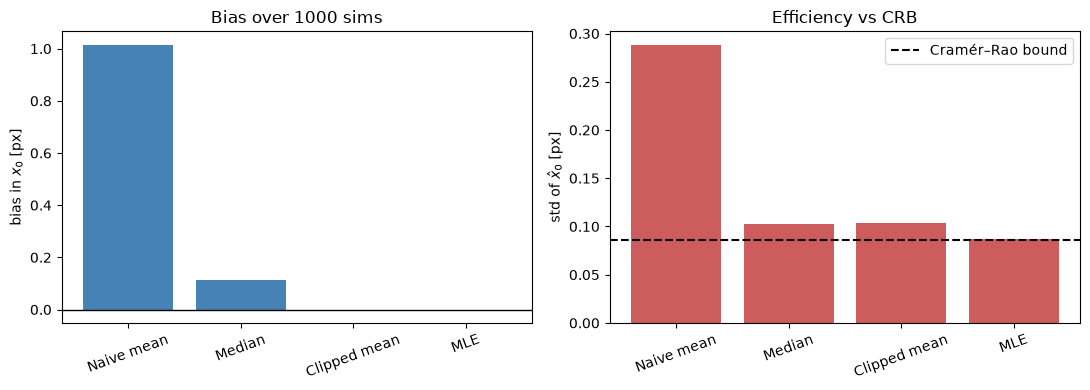


--- Coverage (target 68.3%) ---
Naive mean     10/2000 = 0.5%
Median         917/2000 = 45.9%
Clipped mean   1403/2000 = 70.2%
MLE            1385/2000 = 69.2%



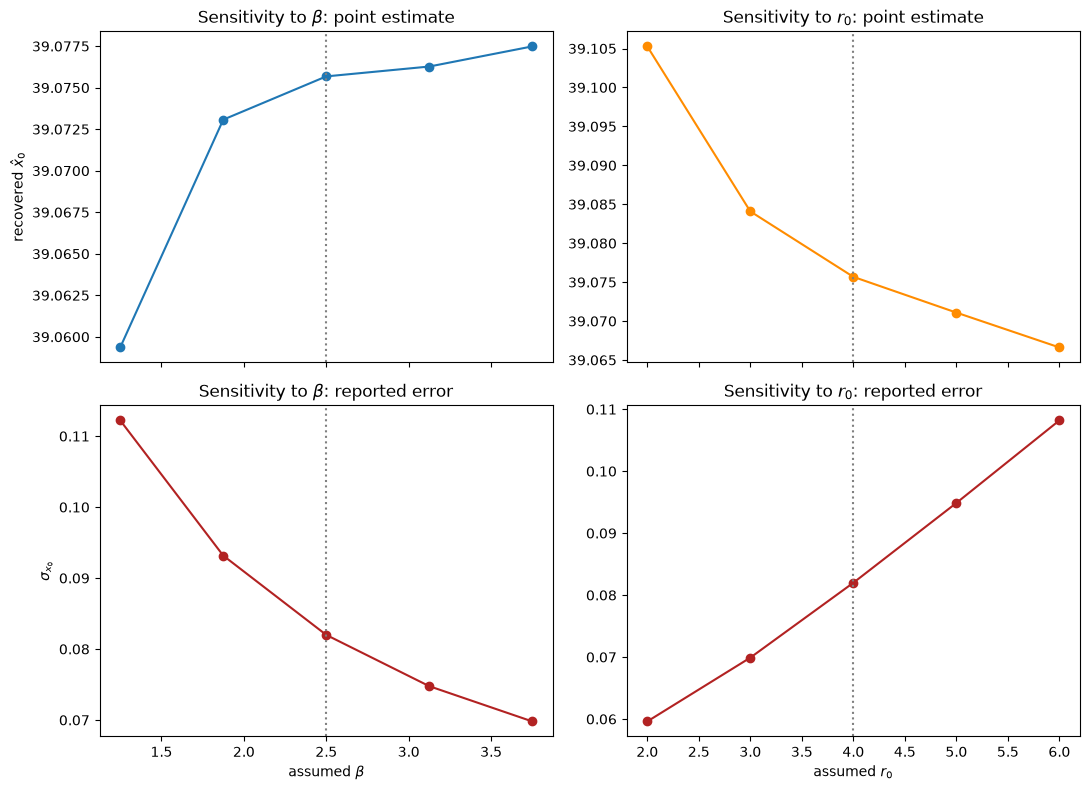

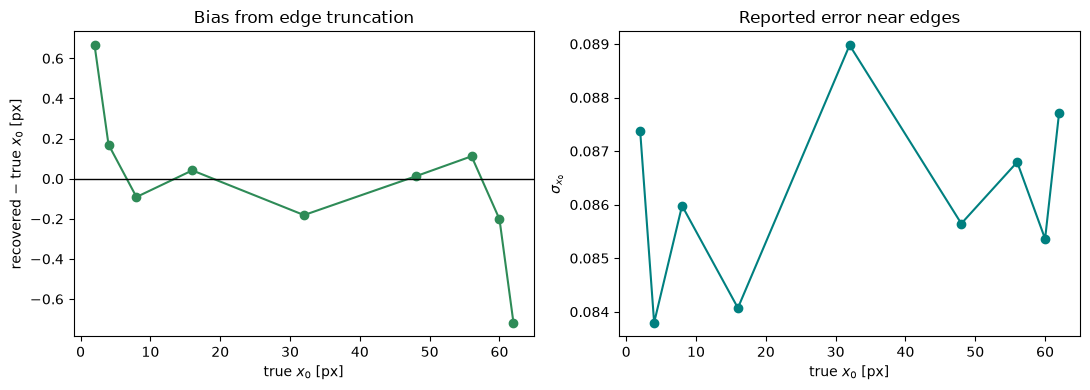

In [3]:
from scipy.optimize import minimize, minimize_scalar, brentq
from scipy.integrate import quad
from scipy.special import gamma as _gamma

rng = np.random.default_rng(0)

# ---------- generic helpers (parametrized so they work for real or simulated data) ----------

def moffat_norm_fn(beta, r0):
    return _gamma(beta) / (r0 * np.sqrt(np.pi) * _gamma(beta - 0.5))

def mixture_pdf(x, x0, fbg, beta=beta, r0=r0, bg_width=bg_width):
    norm = moffat_norm_fn(beta, r0)
    u = (x - x0) / r0
    star = (1 - fbg) * norm * (1 + u**2) ** (-beta)
    return fbg / bg_width + star

def simulate_dataset(x0, fbg, N, beta=beta, r0=r0, window=window, rng=rng):
    """Student-t stand-in for the Moffat (nu = 2*beta-1), with uniform background,
    photons lost if they land outside the window (same as the real detector)."""
    n_bg = rng.binomial(N, fbg)
    n_star = N - n_bg
    nu = 2 * beta - 1
    scale = r0 / np.sqrt(nu)
    star = x0 + rng.standard_t(nu, n_star) * scale
    bg = rng.uniform(window[0], window[1], n_bg)
    x = np.concatenate([star, bg])
    return x[(x >= window[0]) & (x <= window[1])]

def naive_mean_est(x):
    return np.mean(x), np.std(x) / np.sqrt(len(x))

def median_point(x):
    return np.median(x)

def median_est(x, n_boot=1500, rng=rng):
    m = np.median(x)
    boots = [np.median(rng.choice(x, len(x), replace=True)) for _ in range(n_boot)]
    return m, np.std(boots, ddof=1)

def clip_point(x, n_sigma=3.5, max_iter=100):
    mask = np.ones(len(x), dtype=bool)
    for _ in range(max_iter):
        kept = x[mask]
        c = np.mean(kept)
        mad = np.median(np.abs(kept - np.median(kept)))
        rstd = 1.4826 * mad
        new_mask = np.abs(x - c) <= n_sigma * rstd
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return np.mean(x[mask]), mask

def clip_est(x, n_sigma=3.5, n_boot=500, rng=rng):
    m, _ = clip_point(x, n_sigma)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.choice(x, len(x), replace=True)
        boots[b], _ = clip_point(s, n_sigma)
    return m, np.std(boots, ddof=1)

def mle_point(x, beta=beta, r0=r0, bg_width=bg_width, x0_guess=None, fbg_guess=0.1):
    if x0_guess is None:
        x0_guess = np.median(x)
    def nll(p):
        x0v, fbgv = p
        if not (0 < fbgv < 1):
            return np.inf
        return -np.sum(np.log(mixture_pdf(x, x0v, fbgv, beta, r0, bg_width)))
    res = minimize(nll, x0=[x0_guess, fbg_guess], method='Nelder-Mead',
                    bounds=[(x.min(), x.max()), (1e-6, 1 - 1e-6)])
    return res.x[0], res.x[1], nll

def mle_est(x, beta=beta, r0=r0, bg_width=bg_width, x0_guess=None, fbg_guess=0.1):
    x0_mle_, fbg_mle_, nll = mle_point(x, beta, r0, bg_width, x0_guess, fbg_guess)
    nll_min = nll([x0_mle_, fbg_mle_])
    def prof_x0(x0v):
        return minimize_scalar(lambda f: nll([x0v, f]), bounds=(1e-6, 1 - 1e-6), method='bounded').fun
    def d_x0(x0v):
        return prof_x0(x0v) - nll_min - 0.5
    step = 0.05
    xh = x0_mle_ + step
    while d_x0(xh) < 0: xh += step
    xl = x0_mle_ - step
    while d_x0(xl) < 0: xl -= step
    sig = 0.5 * ((brentq(d_x0, x0_mle_, xh) - x0_mle_) + (x0_mle_ - brentq(d_x0, xl, x0_mle_)))
    return x0_mle_, fbg_mle_, sig

def crb_x0_val(x0_val, fbg_val, N, beta=beta, r0=r0, window=window, bg_width=bg_width):
    norm = moffat_norm_fn(beta, r0)
    def dpdx0(x):
        u = (x - x0_val) / r0
        return (1 - fbg_val) * norm * (2 * beta * u / r0) * (1 + u**2) ** (-beta - 1)
    def dpdfbg(x):
        u = (x - x0_val) / r0
        return 1 / bg_width - norm * (1 + u**2) ** (-beta)
    p = lambda x: mixture_pdf(x, x0_val, fbg_val, beta, r0, bg_width)
    I00, _ = quad(lambda x: dpdx0(x)**2 / p(x), *window, limit=200)
    I11, _ = quad(lambda x: dpdfbg(x)**2 / p(x), *window, limit=200)
    I01, _ = quad(lambda x: dpdx0(x)*dpdfbg(x) / p(x), *window, limit=200)
    fisher = N * np.array([[I00, I01], [I01, I11]])
    return np.sqrt(np.linalg.inv(fisher)[0, 0])

# ---------- 3b.1 Closure ----------
x0_truth, fbg_truth = 28.0, 0.25
sim_closure = simulate_dataset(x0_truth, fbg_truth, N)
x0_c, fbg_c, sig_c = mle_est(sim_closure)
print("--- Closure ---")
print(f"recovered x0  = {x0_c:.3f} +- {sig_c:.3f}  (truth {x0_truth}, {abs(x0_c-x0_truth)/sig_c:.2f} sigma away)")
print(f"recovered fbg = {fbg_c:.3f}  (truth {fbg_truth})\n")

# ---------- 3b.2 Bias & efficiency (revised: known truth, not fitted) ----------
n_sims = 1000
x0_assumed, fbg_assumed = x0_truth, fbg_truth   # same known truth as closure/coverage — no circularity
naive_arr, med_arr, clip_arr, mle_arr = (np.empty(n_sims) for _ in range(4))

for i in range(n_sims):
    d = simulate_dataset(x0_assumed, fbg_assumed, N)
    naive_arr[i] = np.mean(d)
    med_arr[i] = median_point(d)
    clip_arr[i], _ = clip_point(d)
    mle_arr[i], _, _ = mle_point(d, x0_guess=median_point(d))

labels = ['Naive mean', 'Median', 'Clipped mean', 'MLE']
arrs = [naive_arr, med_arr, clip_arr, mle_arr]
biases = [np.mean(a) - x0_assumed for a in arrs]
stds = [np.std(a, ddof=1) for a in arrs]
crb_ref = crb_x0_val(x0_assumed, fbg_assumed, N)

print("--- Bias & efficiency ---")
for l, b, s in zip(labels, biases, stds):
    print(f"{l:14s} bias = {b:+.4f} px, error = {s:.4f} px, error/CRB = {s/crb_ref:.2f}")
print(f"CRB(x0) at assumed truth: {crb_ref:.4f} px\n")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].bar(labels, biases, color='steelblue')
axs[0].axhline(0, color='k', lw=1)
axs[0].set_ylabel('bias in $x_0$ [px]')
axs[0].set_title(f'Bias over {n_sims} sims')
axs[0].tick_params(axis='x', rotation=20)

axs[1].bar(labels, stds, color='indianred')
axs[1].axhline(crb_ref, color='k', ls='--', label='Cramér–Rao bound')
axs[1].set_ylabel('std of $\\hat{x}_0$ [px]')
axs[1].set_title('Efficiency vs CRB')
axs[1].tick_params(axis='x', rotation=20)
axs[1].legend()
plt.tight_layout()
plt.show()

# ---------- 3b.3 Coverage ----------
n_sims_cov = 2000
hits = {l: 0 for l in labels}

for i in range(n_sims_cov):
    d = simulate_dataset(x0_truth, fbg_truth, N)

    m, se = naive_mean_est(d)
    hits['Naive mean'] += abs(m - x0_truth) <= se

    med, med_se = median_est(d, n_boot=300)
    hits['Median'] += abs(med - x0_truth) <= med_se

    cm, cm_se = clip_est(d, n_boot=300)
    hits['Clipped mean'] += abs(cm - x0_truth) <= cm_se

    x0h, _, x0h_se = mle_est(d, x0_guess=med)
    hits['MLE'] += abs(x0h - x0_truth) <= x0h_se

print("\n--- Coverage (target 68.3%) ---")
for l in labels:
    print(f"{l:14s} {hits[l]}/{n_sims_cov} = {100*hits[l]/n_sims_cov:.1f}%")
print()

# ---------- 3b.4 Sensitivity to beta, r0 — point estimate AND reported error ----------
beta_vals = beta * np.array([0.5, 0.75, 1.0, 1.25, 1.5])
r0_vals = r0 * np.array([0.5, 0.75, 1.0, 1.25, 1.5])

beta_results = [mle_est(xs.values, beta=bv, r0=r0, x0_guess=x0_mle) for bv in beta_vals]
r0_results = [mle_est(xs.values, beta=beta, r0=rv, x0_guess=x0_mle) for rv in r0_vals]

x0_vs_beta = [r[0] for r in beta_results]; sig_vs_beta = [r[2] for r in beta_results]
x0_vs_r0 = [r[0] for r in r0_results]; sig_vs_r0 = [r[2] for r in r0_results]

fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex='col')
axs[0,0].plot(beta_vals, x0_vs_beta, 'o-'); axs[0,0].axvline(beta, color='gray', ls=':')
axs[0,0].set_ylabel(r'recovered $\hat{x}_0$'); axs[0,0].set_title(r'Sensitivity to $\beta$: point estimate')

axs[1,0].plot(beta_vals, sig_vs_beta, 'o-', color='firebrick'); axs[1,0].axvline(beta, color='gray', ls=':')
axs[1,0].set_xlabel(r'assumed $\beta$'); axs[1,0].set_ylabel(r'$\sigma_{x_0}$')
axs[1,0].set_title(r'Sensitivity to $\beta$: reported error')

axs[0,1].plot(r0_vals, x0_vs_r0, 'o-', color='darkorange'); axs[0,1].axvline(r0, color='gray', ls=':')
axs[0,1].set_title(r'Sensitivity to $r_0$: point estimate')

axs[1,1].plot(r0_vals, sig_vs_r0, 'o-', color='firebrick'); axs[1,1].axvline(r0, color='gray', ls=':')
axs[1,1].set_xlabel(r'assumed $r_0$'); axs[1,1].set_title(r'Sensitivity to $r_0$: reported error')
plt.tight_layout(); plt.show()

# ---------- edge-truncation: bias AND error ----------
x0_test_positions = np.array([2, 4, 8, 16, 32, 48, 56, 60, 62])
loss_bias, loss_sigma = [], []
for x0t in x0_test_positions:
    d = simulate_dataset(x0t, fbg_assumed, N)
    x0h, _, sig_h = mle_est(d, x0_guess=median_point(d))
    loss_bias.append(x0h - x0t)
    loss_sigma.append(sig_h)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(x0_test_positions, loss_bias, 'o-', color='seagreen'); axs[0].axhline(0, color='k', lw=1)
axs[0].set_xlabel('true $x_0$ [px]'); axs[0].set_ylabel('recovered $-$ true $x_0$ [px]')
axs[0].set_title('Bias from edge truncation')

axs[1].plot(x0_test_positions, loss_sigma, 'o-', color='teal')
axs[1].set_xlabel('true $x_0$ [px]'); axs[1].set_ylabel(r'$\sigma_{x_0}$')
axs[1].set_title('Reported error near edges')
plt.tight_layout(); plt.show()

**WHAT THE CHECKS FOUND:**

First of all, we can see that the $x_0$ and $f_{bg}$ values obtained in the Closure section are quite close to the truth value, indicating that the mixture model is likely performing as intended. This is backed up by the bias and efficiency test, in which we can compare the different models. As discussed in part 2, it's still very clear that the naive model is very biased and has significantly overestimated uncertainties. Meanwhile, the median model is more robust but still biased, and the clipped mean and mixture models are relatively unbiased. The uncertainties, however, make it clear that the mixture model wins as it effectively matches the Cramer-Rao bound while the clipped mean model, despite similarly insignificant bias, has uncertainties about 21% above the Cramer-Rao bound.

Initially when I tested, the coverage check seemed to slightly fail (~3-5% too high) somewhat consistently for the mixed model, however I was unsure whether that was simply chance due to running the test only a few hundred times or an actual result of the model. So I decided to instead bump the number of tests from the previous 150-500 that I had tried up to 2000, and now it seems likely that was just chance, as we see good coverage at 69.2% of the tests. The clipped mean is similarly quite close, just under 2% off the expected value, while the median covers it a bit under half the time and the mean covers the actual value less than 1 in 100 cases. That initially surprised me a lot, and I wondered if I had messed something up. But upon looking closer, the bias in this case is over 1 pixel, and the $1\sigma$ error is 0.2879, so the bias is $3.52\sigma$ from the real value, which equates to being outside about 99.98%, so 10/2000 tests covering the true value due to chance is actually reasonable (if even a bit high).

As for the sensitivity, it's somewhat interesting how much you need to change $\beta$ and $r_0$ to see notable changes in the computed $x_0$, though we can see that the parameters make a much more significant effect on the errors. Interestingly, both effects almost look like they are flipped, for example with increasing $\beta$ causing $x_0$ to increase quickly and then level off, while increasing $r_0$ causes $x_0$ to decrease quickly before leveling off. It's not exactly a perfect flip in both $x_0$ and error cases, but it's interesting how it seems pretty close despite the two parameters being used differently in the likelihood function. Meanwhile, the edge truncation looks as expected: if we cut off some of the data by setting $x_0$ close to 0, then the background signals become relatively larger and bias the estimated $x_0$ to the right. Similarly, a point source located too close to the edge near $x=64$ will be biased negatively.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

Part 1: No AI was used.

Part 2: Claude was used to write base code for the sigma-clipped mean, mixture model, and Cramer-Rao bound calculations. The other stuff, including the analysis, was done without the assistance of AI. It picked sigma=3 for clipping initially, which cut perhaps a bit too much, so I chose 3.5 instead. It also used basic np.std for the error, and I had to correct it by using bootstrapping (without that the error would be lower than the Cramer-Rao bound with a low enough choice of sigma, including sigma=3). Claude also initially used the Hessian to compute the mixture model uncertainty because I forgot to specify that I wanted the curvature method, so that needed to be changed afterward (though I confirmed the bounds were identical in both cases up to the displayed precision).

Part 3: The base plan was written without AI assistance, but the implementation used Claude to write the boilerplate needed to simulate and plot based on the models used in part 2. For the most part Claude was correct with the code, it just didn't want to plot the sensitivity initially and at the start made some changes to the models I had used in part 2 (particularly estimating error with the curvature and bootstrapping), instead choosing initially to revert to its standard approach for errors so it could run faster. However, upon clarification Claude provided the code as initially requested so it wasn't testing models that were slightly different from what I had in part 2. All the analysis of the results were done without AI help.